## TMG metrics info

### About the metrics

#### Dot Product (prod)

The Dot Product [[ref](https://link.springer.com/article/10.1007/s10851-012-0377-4)] only takes into consideration the principal eigenvectors of the tensors. The result varies between 0 and 1 according to the angle between the vectors: equals to one if the vectors are parallel and equals to zero if the vectors are orthogonal.

$$ d_{prod}(T_i, T_j) = |e_{1i} \cdot e_{1j}| $$

Since the Dot Product is a similarity measure, the TMG calculates the minimal similarity instead of the maximal dissimilarity. The negative of the resulting image will be the output of the TMG (maintaining the same pattern as for the other measures).

#### Frobenius Norm (frob)

The Frobenius Norm [[ref](https://d1wqtxts1xzle7.cloudfront.net/36596302/10-libre.pdf?1423654983=&response-content-disposition=inline%3B+filename%3DSimilarity_Measures_for_Matching_Diffusi.pdf&Expires=1740192315&Signature=QQ2WuCHEm7-shVWxhap6APbYFRD8k071jTxU5oejSgpOJl8E4k7XMSEjDNJuMkViu8o32J-1oxz0WBijQ2LcQnUZMFJpD107FJevxbS5kGzrx3TXn73rmxlQxtD1yBJJF732G8rvdFQQk0EuBpSLyyFmRPHKuSS47CcnzkCKzgjRh473FSs5-8mPLAG2dTTqSOxrAu1Fq7nU~fBXaDad6GaGYqG02KT30eaqjHatd5Jur0vTTE6JxEhiBTWckTu3I1XVqbsNE2td0mm2E9VO4t3Fqhj442SX-71-T359mkHxOl08e6uLrczkeCnXnl6P1Pnf-KAdz5FRRng5LDXrQw__&Key-Pair-Id=APKAJLOHF5GGSLRBV4ZA)] is an Euclidean distance measure between the tensors, as follows:

$$ d_{frob}(T_i,T_j) = \sqrt{trace((T_i - T_j)^2)} $$

This dissimilarity measure is not invariant to affine transformations. However, it presents a linear response to differences in anisotropy and trace.

#### Log-Euclidean distance (logE)

The logE [[ref](https://onlinelibrary.wiley.com/doi/10.1002/mrm.20965)] is an Euclidean distance measure between the logarithm of the tensors, close related to the Frobenius Norm.

$$ d_{logE}(T_i,T_j) = \sqrt{trace((\log(T_i) - \log(T_j))^2)} $$

From the equation above, it is possible to see that symmetric matrices with null or negative eigenvalues are at an infinite distance from any tensor. To overcome this problem, $\log(T_i)$ was replaced with $E_i \cdot \log(100\lambda_i + 1)I \cdot E_i^T$, where $E$ corresponds to the matrix of eigenvectors, $\lambda$ corresponds to the eigenvalues, and $I$ is the identity matrix.

#### J-Divergence (Jdiv)

The J-divergence [[ref](https://ieeexplore.ieee.org/document/1514547)] is a tensorial "distance" measure, based on concepts of theory information. The measure is not a true distance, since it violates the triangle inequality. However, it is a computationally efficient approximation of the Rao's distance and is invariant to affine transformations.

$$ d_{Jdiv}(T_i,T_j) = \frac{1}{2} \sqrt{trace(T_i^{-1}T_j + T_j^{-1}T_i) - 2n} $$

with $n$ being the size of the square matrix $T$.

### Properties of the metrics

**Obs.: Results using prod are shown without any modification. Since it is a similarity measure, its results are the "opposite" of the other metrics (higher values indicate more similarity instead of more dissimilarity).**

#### Results by changing only the size of the tensors (same orientation and anisotropy)

The image below exemplifies the change in size.

![Size](figs/Size.png)

The results below were obtained using tensors with eigenvalues = $(0.01, 0.005, 0.002) \cdot n$ with $n$ ranging from 1 to 100.

![Size results](figs/Size_results.png)

#### Results by changing only the anisotropy of the tensors (same orientation and size/trace)

The image below exemplifies the change in anisotropy.

![Anisotropy](figs/Anisotropy.png)

The results below were obtained by changing the tensors from eigenvalues = $(0.3, 0.3, 0.3)$ to eigenvalues = $(0.895 , 0.0025, 0.0025)$, with a step of $(+0.005, -0.0025, -0.0025)$.

![Anisotropy results](figs/Anisotropy_results.png)

#### Results by changing the orientation of the eigenvectors (keeping the eigenvalues constant)

The rotations were applied on the first eigenvector (e1), second eigenvector (e2), and third eigenvector (e3), respectively. The images below exemplify these rotations.

![Rotating e1](figs/Rotation_e1.png)
![Rotating e2](figs/Rotation_e2.png)
![Rotating e3](figs/Rotation_e3.png)

Results considering a linear tensor (Jdiv doesn't work if one of the eigenvalues is exactly zero):

![Linear tensor](figs/Orientation_linear.png)

Results considering an almost linear tensor:

![Almost linear tensor](figs/Orientation_almost_linear.png)

Results considering a planar tensor (Jdiv doesn't work if one of the eigenvalues is exactly zero):

![Planar tensor](figs/Orientation_planar.png)

Results considering an almost planar tensor:

![Almost planar tensor](figs/Orientation_almost_planar.png)

Results considering a spherical tensor:

![Spherical tensor](figs/Orientation_spherical.png)

Results considering an intermediate tensor:

![Intermediate tensor](figs/Orientation_intermediate.png)

## TMG on synthetic data

In [1]:
import sys
sys.path.insert(0, '../')
from lib_TMG import SyntheticData, Visualization
from lib_TMG.TMG import TMG
import numpy as np
import matplotlib.pyplot as plt

/home/caio/miniconda3/envs/test-parc-streamlit/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Select synthetic structure (Torus, Kissing or V)
synthetic_structure = "Torus"

# Creating a synthetic Torus
if synthetic_structure == "Torus":
    # Defining the eigenvalues (background eigenvalues can be different)
    l1, l2, l3 = (1, 0.2, 0.2)
    n_slices = 24
    r = 3
    R = 6
    eigvals,eigvects = SyntheticData.sintTorus(l1, l2, l3, n_slices, R, r, l1, l2, l3, background=True)
    print(eigvects.shape)

# Creating a synthetic Kissing
elif synthetic_structure == "Kissing":
    # Defining the eigenvalues (background eigenvalues can be different)
    l1, l2, l3 = (1, 0.2, 0.2)
    n_slices = 24
    r = 3
    R = 11
    eigvals,eigvects = SyntheticData.sintKissing(l1, l2, l3, n_slices, R, r, l1, l2, l3, background=True)
    print(eigvects.shape)

# Creating a synthetic V
elif synthetic_structure == "V":
    # Defining the eigenvalues (background eigenvalues can be different)
    l1, l2, l3 = (1, 0.2, 0.2)
    n_slices = 24
    r = 5
    # Slope of the line
    a = 1.5
    eigvals,eigvects = SyntheticData.sintV(l1, l2, l3, n_slices, r, a, l1, l2, l3, background=True)
    print(eigvects.shape)

(24, 24, 24, 3, 3)


In [3]:
# Viewing a specific slice
selected_slice = n_slices//2
axis = 'z'
Visualization.tensorSlice(eigvals, eigvects, axis, selected_slice, bg = (1, 1, 1))

In [4]:
# Dynamic view of slices
Visualization.dynamicTensorSlice(eigvals, eigvects, bg = (0.5, 0.5, 0.5))

**Obs.: The TMG results using frob, logE, and Jdiv look basically the same in the examples below. Indeed, frob and logE results look very similar even using real data but differ in scale. On the other hand, Jdiv results are harder to deal with when using real data, with some voxels presenting extremely high values.**

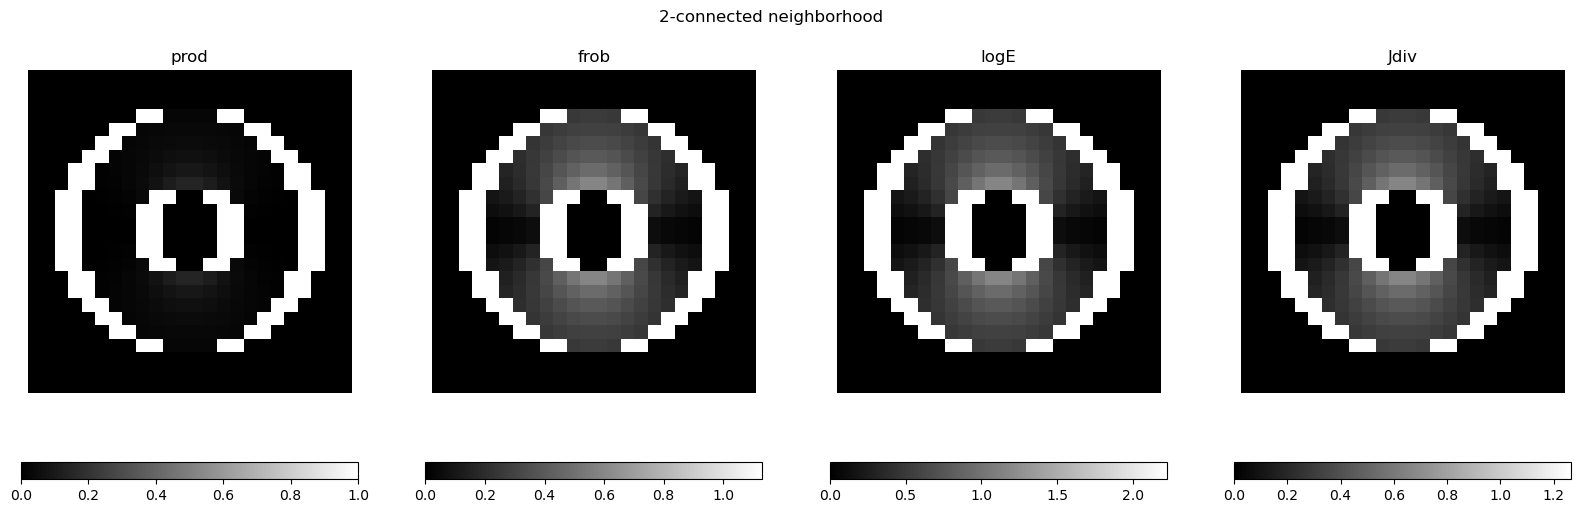

In [5]:
neighborhood = 2
vis_info = 'x'
metrics = ['prod', 'frob', 'logE', 'Jdiv']
TMG_imgs_2 = []

for m in metrics:
    temp = TMG(eigvals, eigvects, m, neighborhood, vis_info)
    TMG_imgs_2.append((temp, m))

slice_index = n_slices//2

plt.figure(figsize=(20,6))
plt.suptitle('2-connected neighborhood')

for n,img in enumerate(TMG_imgs_2):
    plt.subplot(1,4,n+1)
    plt.imshow(np.transpose(TMG_imgs_2[n][0][...,slice_index], (1,0)), cmap='gray')
    plt.title(TMG_imgs_2[n][1])
    plt.colorbar(orientation='horizontal')
    plt.axis('off')

plt.show()

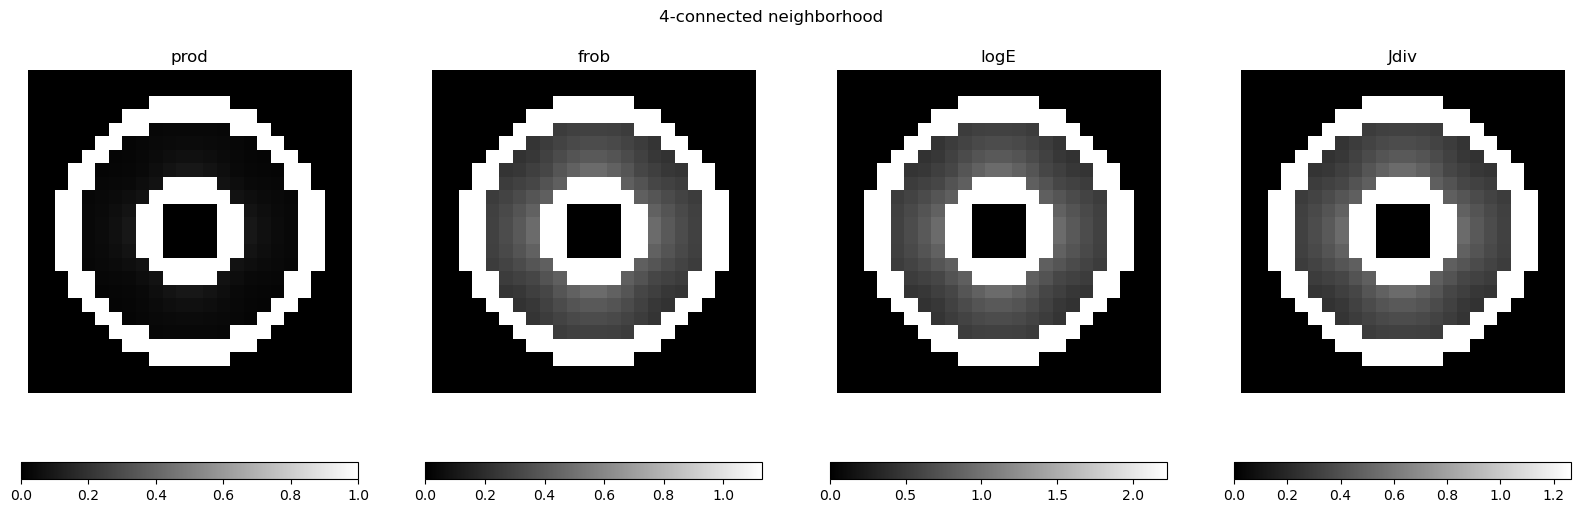

In [6]:
neighborhood = 4
vis_info = 'xy'
metrics = ['prod', 'frob', 'logE', 'Jdiv']
TMG_imgs_4 = []

for m in metrics:
    temp = TMG(eigvals, eigvects, m, neighborhood, vis_info)
    TMG_imgs_4.append((temp, m))

slice_index = n_slices//2

plt.figure(figsize=(20,6))
plt.suptitle('4-connected neighborhood')

for n,img in enumerate(TMG_imgs_4):
    plt.subplot(1,4,n+1)
    plt.imshow(np.transpose(TMG_imgs_4[n][0][...,slice_index], (1,0)), cmap='gray')
    plt.title(TMG_imgs_4[n][1])
    plt.colorbar(orientation='horizontal')
    plt.axis('off')

plt.show()

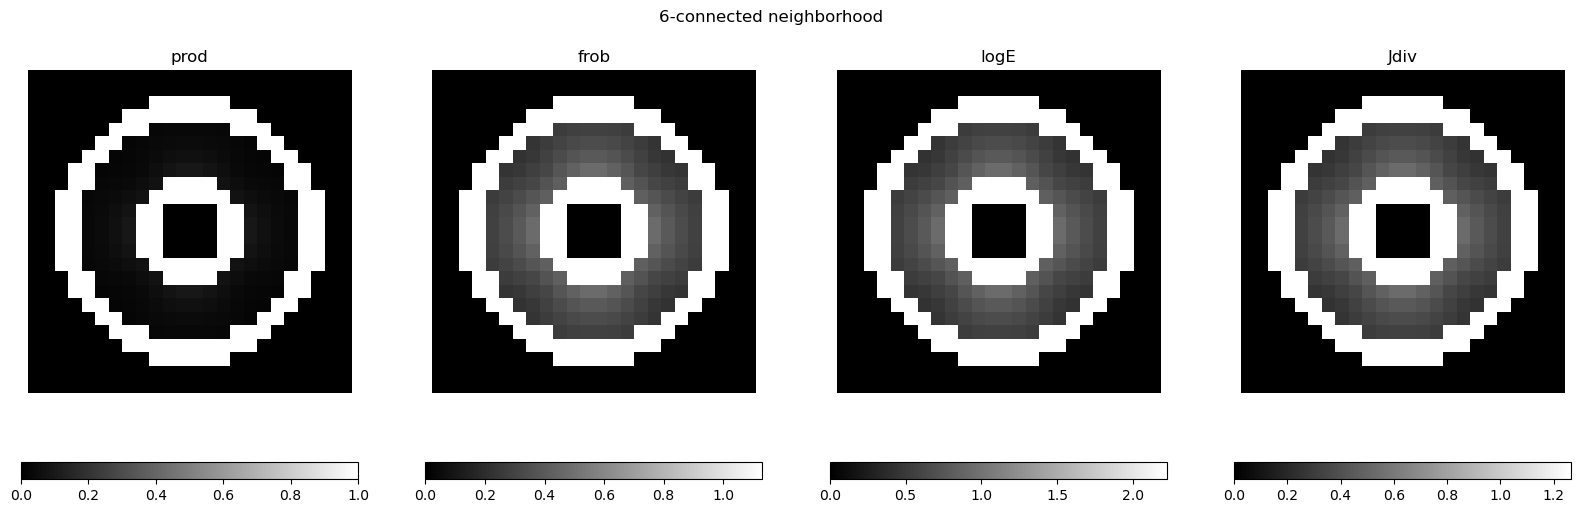

In [7]:
neighborhood = 6
metrics = ['prod', 'frob', 'logE', 'Jdiv']
TMG_imgs_6 = []

for m in metrics:
    temp = TMG(eigvals, eigvects, m, neighborhood)
    TMG_imgs_6.append((temp, m))

slice_index = n_slices//2

plt.figure(figsize=(20,6))
plt.suptitle('6-connected neighborhood')

for n,img in enumerate(TMG_imgs_6):
    plt.subplot(1,4,n+1)
    plt.imshow(np.transpose(TMG_imgs_6[n][0][...,slice_index], (1,0)), cmap='gray')
    plt.title(TMG_imgs_6[n][1])
    plt.colorbar(orientation='horizontal')
    plt.axis('off')

plt.show()

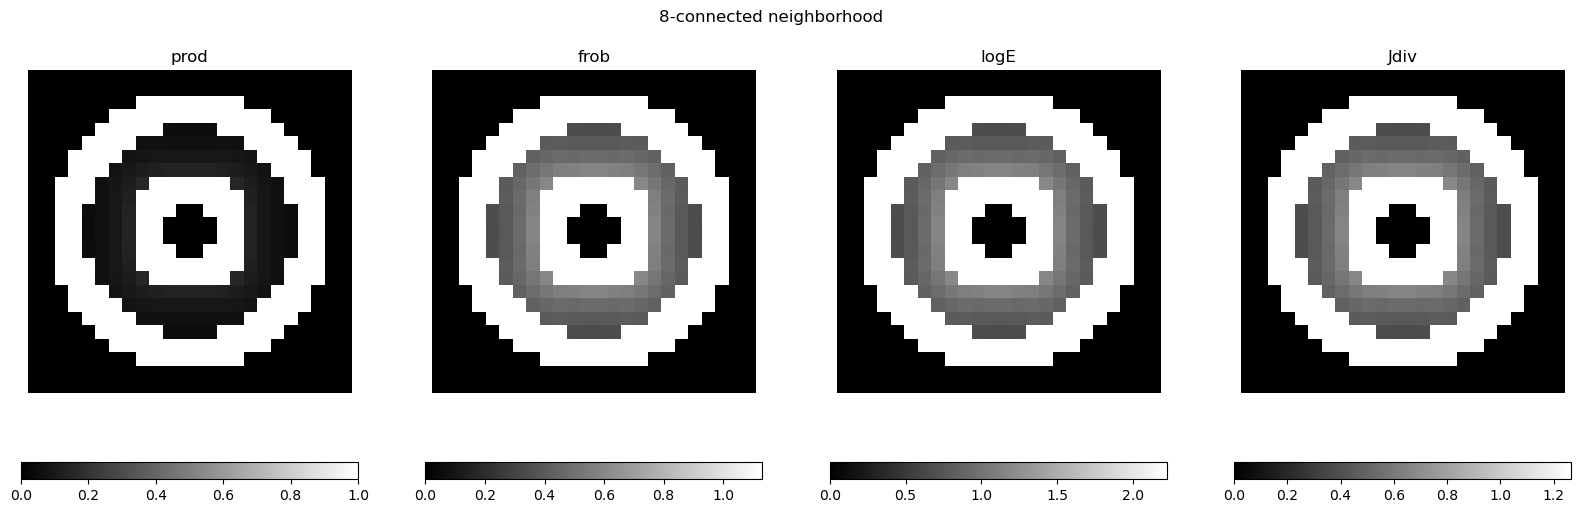

In [9]:
neighborhood = 8
vis_info = 'xy'
metrics = ['prod', 'frob', 'logE', 'Jdiv']
TMG_imgs_8 = []

for m in metrics:
    temp = TMG(eigvals, eigvects, m, neighborhood, vis_info)
    TMG_imgs_8.append((temp, m))

slice_index = n_slices//2

plt.figure(figsize=(20,6))
plt.suptitle('8-connected neighborhood')

for n,img in enumerate(TMG_imgs_8):
    plt.subplot(1,4,n+1)
    plt.imshow(np.transpose(TMG_imgs_8[n][0][...,slice_index], (1,0)), cmap='gray')
    plt.title(TMG_imgs_8[n][1])
    plt.colorbar(orientation='horizontal')
    plt.axis('off')

plt.show()